In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

import sys
PROJECT_ROOT = Path.cwd().resolve().parents[0]  # remonte de notebooks -> racine projet
sys.path.append(str(PROJECT_ROOT))

from src.data.cityscapes_labels import GROUPS
from src.data.cityscapes_tfdata import make_cityscapes_ds

CSV_PATH = Path(f"{PROJECT_ROOT}/data/manifests/cityscapes_pairs.csv")
df = pd.read_csv(CSV_PATH)

ROOT = Path(PROJECT_ROOT / "data")


In [4]:
df["img_abs"] = df["image_path"].apply(lambda p: str(ROOT / p))
df["mask_abs"] = df["mask_path"].apply(lambda p: str(ROOT / p))

train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)

len(train_df), len(val_df)

(2975, 500)

In [5]:
TARGET_HW = (256, 512)
BATCH = 4

ds_train = make_cityscapes_ds(
    train_df["img_abs"].tolist(),
    train_df["mask_abs"].tolist(),
    target_hw=TARGET_HW,
    batch_size=BATCH,
    training=True,
    cache=False,
)

ds_val = make_cityscapes_ds(
    val_df["img_abs"].tolist(),
    val_df["mask_abs"].tolist(),
    target_hw=TARGET_HW,
    batch_size=BATCH,
    training=False,
    cache=False,
)

E0000 00:00:1772274640.684939   13982 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1772274640.691336   13982 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [6]:
imgs, masks, weights = next(iter(ds_train.take(1)))
print(imgs.shape, masks.shape, weights.shape)
print("weights unique:", np.unique(weights.numpy()))
print("imgs:", imgs.shape, imgs.dtype, "min/max:", float(tf.reduce_min(imgs)), float(tf.reduce_max(imgs)))
print("masks:", masks.shape, masks.dtype)

u = np.unique(masks.numpy())
print("unique mask values:", u)
print("unique group names:", [GROUPS[i] for i in u])

(4, 256, 512, 3) (4, 256, 512) (4, 256, 512)
weights unique: [0. 1.]
imgs: (4, 256, 512, 3) <dtype: 'float32'> min/max: 0.03333333507180214 1.0
masks: (4, 256, 512) <dtype: 'int32'>
unique mask values: [0 1 2 3 4 5 6 7]
unique group names: ['flat', 'human', 'vehicle', 'construction', 'object', 'nature', 'sky', 'void']


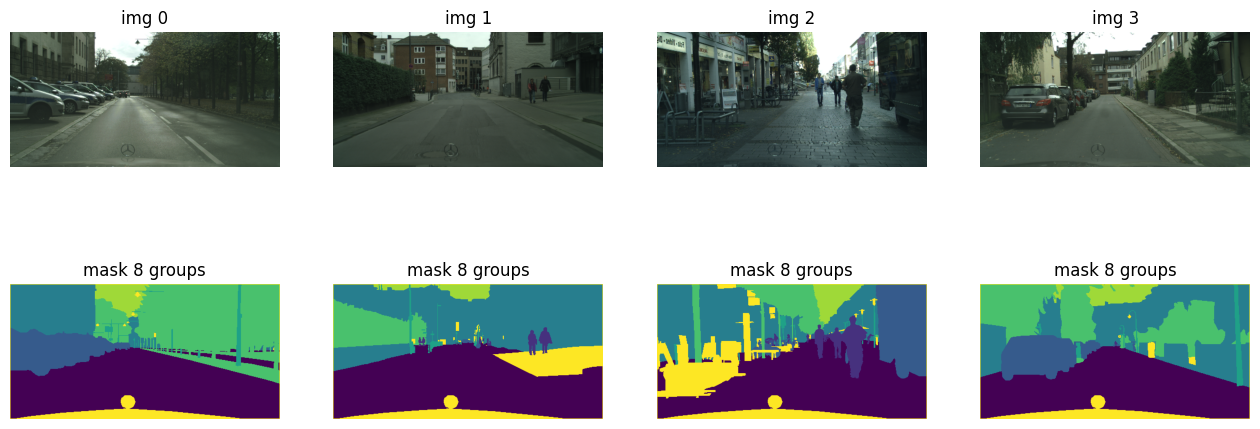

In [7]:
imgs_np = imgs.numpy()
masks_np = masks.numpy()

plt.figure(figsize=(16,6))
for i in range(min(BATCH, 4)):
    plt.subplot(2,4,i+1)
    plt.imshow(imgs_np[i])
    plt.axis("off")
    plt.title(f"img {i}")

    plt.subplot(2,4,4+i+1)
    plt.imshow(masks_np[i], vmin=0, vmax=len(GROUPS)-1)
    plt.axis("off")
    plt.title("mask 8 groups")
plt.show()